In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import date, timedelta

In [ ]:
# Task 1 → Natural Gas Price Estimator  

In [2]:
df=pd.read_csv('Nat_Gas.csv', parse_dates=['Dates'])
prices = df['Prices'].values
dates = df['Dates'].values
print(df.shape)

(48, 2)


C:\Users\Manju\AppData\Local\Temp\ipykernel_22752\3697933120.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df=pd.read_csv('Nat_Gas.csv', parse_dates=['Dates'])


In [3]:
df.head(10)

,Dates,Prices
0,2020-10-31,10.10
1,2020-11-30,10.30
2,2020-12-31,11.00
3,2021-01-31,10.90
4,2021-02-28,10.90
5,2021-03-31,10.90
6,2021-04-30,10.40
7,2021-05-31,9.84
8,2021-06-30,10.00
9,2021-07-31,10.10


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Dates   48 non-null     datetime64[us]
 1   Prices  48 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 900.0 bytes
None


C:\Users\Manju\AppData\Local\Temp\ipykernel_22752\868007311.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


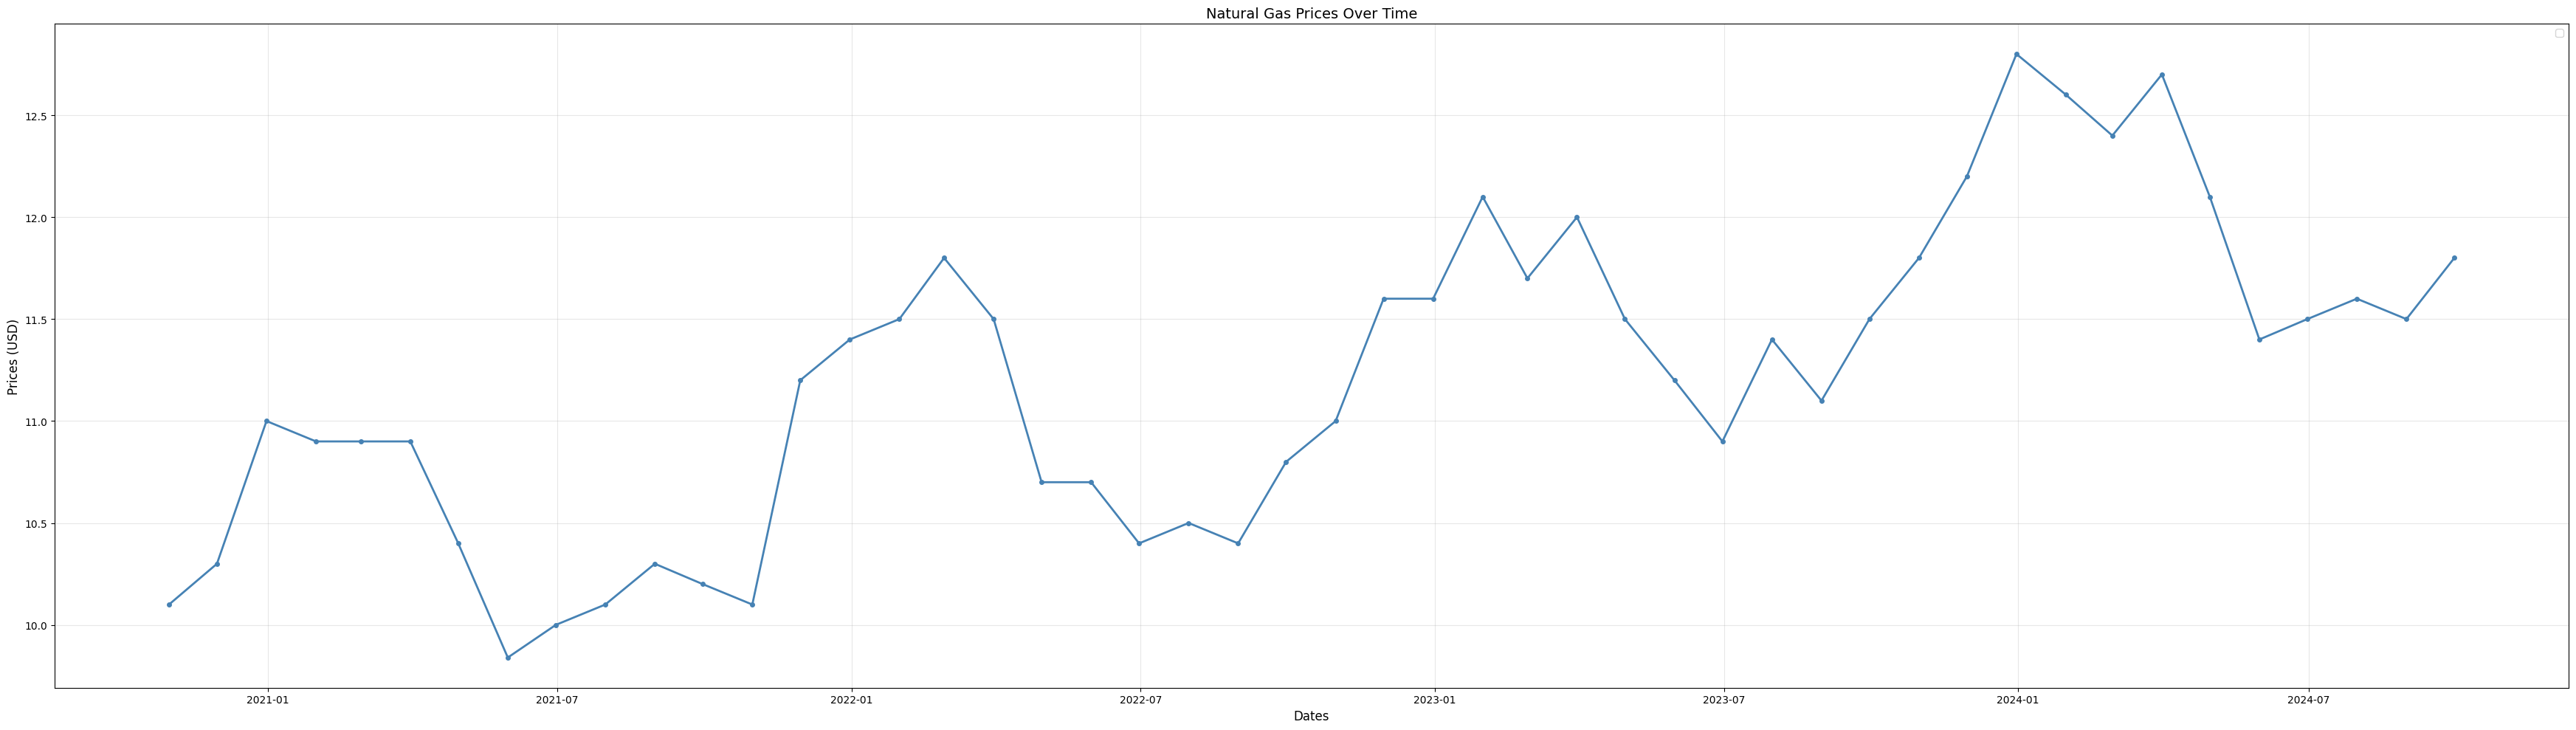

In [5]:
plt.figure(figsize=(35, 10))  
plt.plot(df['Dates'], df['Prices'], color='steelblue', linewidth=2, marker='o', markersize=4,)
plt.xlabel('Dates', fontsize=12)
plt.ylabel('Prices (USD)', fontsize=12)
plt.title('Natural Gas Prices Over Time', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)   
plt.tight_layout()          
plt.show()

In [6]:
start_date = date(2020, 10, 31)
end_date   = date(2024, 9, 30)

# Build list of month-end dates
months = []
year   = start_date.year
month  = start_date.month + 1

while True:
    current = date(year, month, 1) + timedelta(days=-1)
    months.append(current)
    if current.month == end_date.month and current.year == end_date.year:
        break
    else:
        month = ((month + 1) % 12) or 12
        if month == 1:
            year += 1

# Convert to days from start
days_from_start = [(day - start_date).days for day in months]
time = np.array(days_from_start)

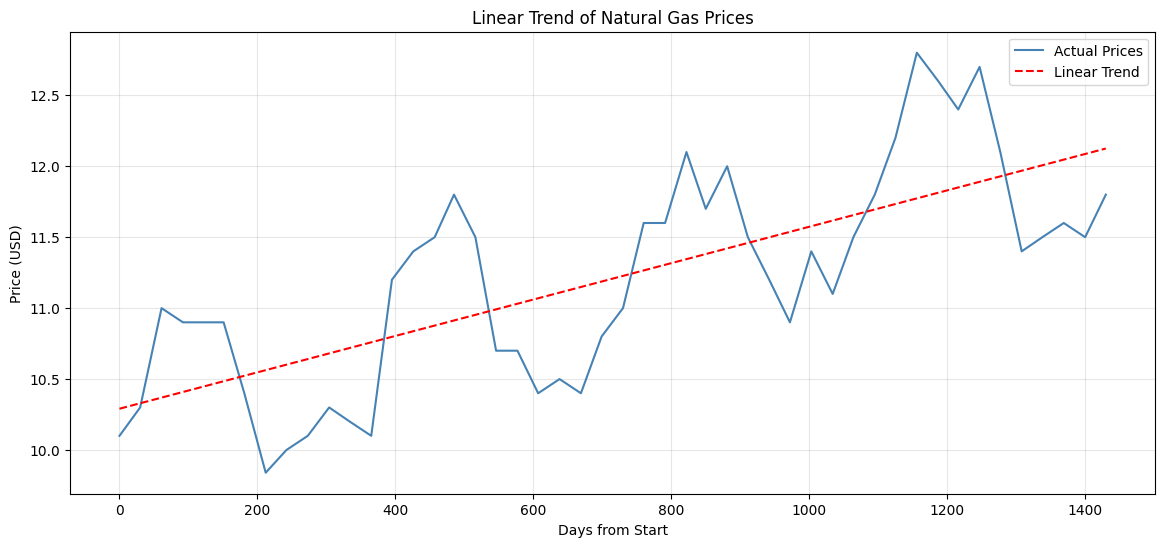

Slope     : 0.001282  (price increase per day)
Intercept : 10.2910 (starting price)


In [7]:
def simple_regression(x, y):
    xbar      = np.mean(x)
    ybar      = np.mean(y)
    slope     = np.sum((x - xbar) * (y - ybar)) / np.sum((x - xbar)**2)
    intercept = ybar - slope * xbar
    return slope, intercept

slope, intercept = simple_regression(time, prices)

# Plot the trend line
plt.figure(figsize=(14, 6))
plt.plot(time, prices, label='Actual Prices', color='steelblue')
plt.plot(time, time * slope + intercept, 
         label='Linear Trend', 
         color='red', 
         linestyle='--')
plt.xlabel('Days from Start')
plt.ylabel('Price (USD)')
plt.title('Linear Trend of Natural Gas Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Slope     : {slope:.6f}  (price increase per day)")
print(f"Intercept : {intercept:.4f} (starting price)")


In [8]:
sin_prices = prices - (time * slope + intercept)
sin_time = np.sin(time * 2 * np.pi / 365)
cos_time = np.cos(time * 2 * np.pi / 365)
# Bilinear regression to find wave shape
def bilinear_regression(y, x1, x2):
    slope1 = np.sum(y * x1) / np.sum(x1 ** 2)
    slope2 = np.sum(y * x2) / np.sum(x2 ** 2)
    return slope1, slope2
slope1, slope2 = bilinear_regression(sin_prices, sin_time, cos_time)
# Recover amplitude and phase shift
amplitude = np.sqrt(slope1**2 + slope2**2)
shift     = np.arctan2(slope2, slope1)
print(f"\nAmplitude : {amplitude:.4f} (how much prices swing)")
print(f"Shift     : {shift:.4f}     (where wave starts)")


Amplitude : 0.6658 (how much prices swing)
Shift     : -0.0622     (where wave starts)


In [9]:
def get_price(input_date):
    # Convert input to timestamp
    date_ts = pd.Timestamp(input_date)
    # Convert to days from start
    days = (date_ts - pd.Timestamp(start_date)).days
    # Check if exact date exists in data
    if days in days_from_start:
        return round(prices[days_from_start.index(days)], 2)
    # Otherwise use: trend + sine wave
    trend        = days * slope + intercept
    seasonal     = amplitude * np.sin(days * 2 * np.pi / 365 + shift)
    price        = trend + seasonal
    return round(float(price), 2)

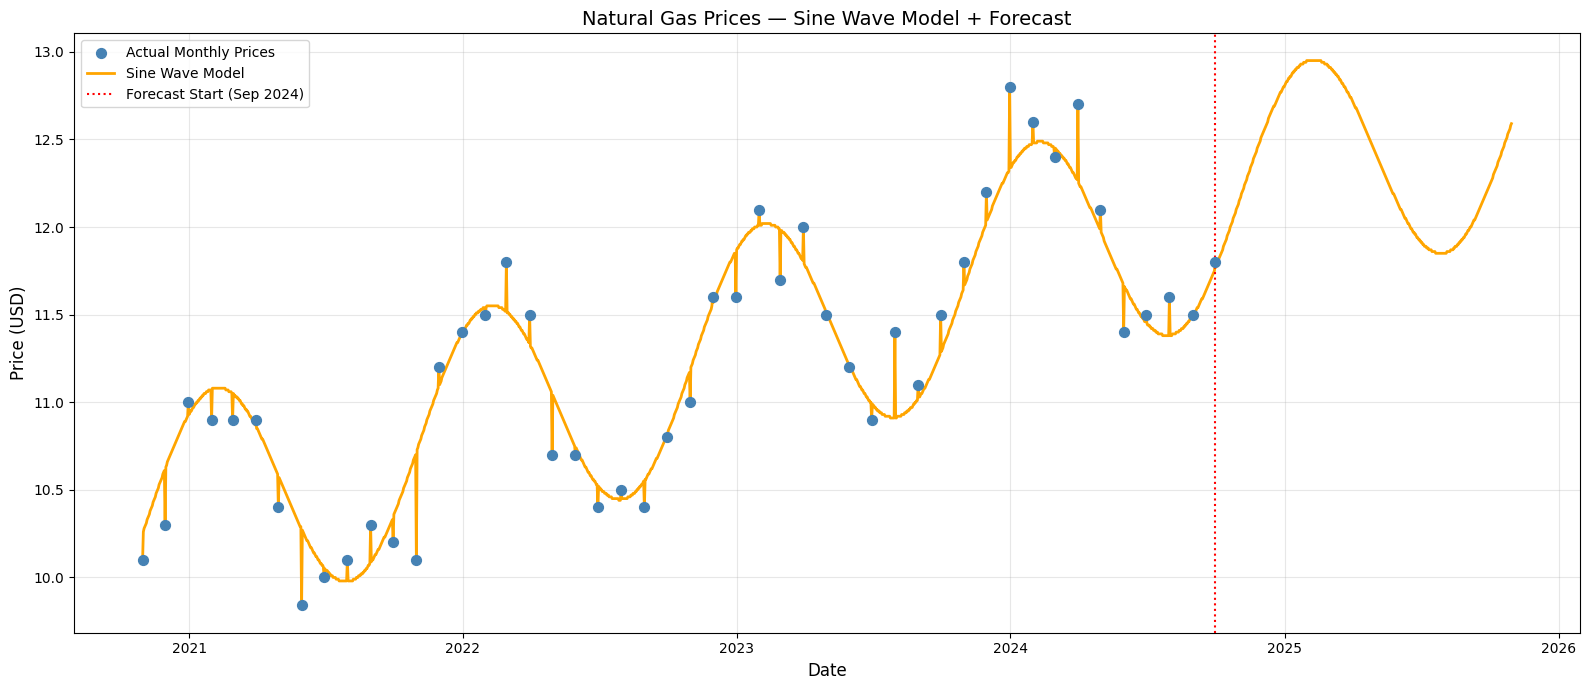

In [10]:
continuous_dates = pd.date_range(
    start=pd.Timestamp(start_date),
    end=pd.Timestamp('2025-10-30'),   # 1 year extrapolation
    freq='D'
)
predicted_prices = [get_price(str(d.date())) for d in continuous_dates]

plt.figure(figsize=(16, 7))

# Actual monthly data points
plt.scatter(dates, prices, 
            color='steelblue', 
            zorder=5, s=50, 
            label='Actual Monthly Prices')

# Full model curve
plt.plot(continuous_dates, predicted_prices,
         color='orange',
         linewidth=2,
         label='Sine Wave Model')

# Vertical line — where forecast starts
plt.axvline(x=pd.Timestamp(end_date),
            color='red',
            linestyle=':',
            linewidth=1.5,
            label='Forecast Start (Sep 2024)')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.title('Natural Gas Prices — Sine Wave Model + Forecast', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
print("past dates :", get_price('2020-12-25'))
print("past dates :", get_price('2022-06-10'))
print("past dates :", get_price('2023-10-31'))


past dates : 10.88
past dates : 10.66
past dates : 11.8


In [12]:
print("future dates :", get_price('2025-03-15'))
print("future dates :", get_price('2025-05-20'))
print("future dates :", get_price('2025-11-30'))

future dates : 12.84
future dates : 12.24
future dates : 12.97


In [ ]:
# Task 2 → Storage Contract Pricing   

In [13]:
from datetime import date
import math

def price_contract(in_dates, in_prices, 
                   out_dates, out_prices, 
                   rate, storage_cost_rate, 
                   total_vol, 
                   injection_withdrawal_cost_rate):
    
    volume   = 0
    buy_cost = 0
    cash_in  = 0

    # ---- Sort ALL dates together chronologically ----
    all_dates = sorted(set(in_dates + out_dates))

    for start_date in all_dates:

        # ---- INJECTION DATE ----
        if start_date in in_dates:
            if volume <= total_vol - rate:
                volume   += rate

                # Purchase cost
                buy_cost += rate * in_prices[in_dates.index(start_date)]

                # Injection cost
                buy_cost += rate * injection_withdrawal_cost_rate

                print(f"Injected gas on {start_date} at "
                      f"${in_prices[in_dates.index(start_date)]}")
            else:
                print(f"Injection NOT possible on {start_date} "
                      f"— storage full!")

        # ---- WITHDRAWAL DATE ----
        elif start_date in out_dates:
            if volume >= rate:
                volume  -= rate

                # Revenue from selling
                cash_in += rate * out_prices[out_dates.index(start_date)]

                # Withdrawal cost
                cash_in -= rate * injection_withdrawal_cost_rate

                print(f"Withdrew gas on {start_date} at "
                      f"${out_prices[out_dates.index(start_date)]}")
            else:
                print(f"Withdrawal NOT possible on {start_date} "
                      f"— insufficient gas!")

    # ---- Storage Cost (fixed monthly fee) ----
    months = math.ceil(
        (max(out_dates) - min(in_dates)).days // 30
    )
    store_cost = months * storage_cost_rate

    # ---- Final Contract Value ----
    contract_value = cash_in - store_cost - buy_cost
    print("\nCONTRACT SUMMARY :")
    print(f"Cash In        : ${cash_in:>15,.2f}")
    print(f"Buy Cost       : ${buy_cost:>15,.2f}")
    print(f"Months Stored  : {months}")
    print(f"Storage Cost   : ${store_cost:>15,.2f}")
    print(f"CONTRACT VALUE : ${contract_value:>15,.2f}")
    return contract_value


# ---- Test with Official Sample Inputs ----
in_dates  = [date(2022,1,1), date(2022,2,1), 
             date(2022,2,21), date(2022,4,1)]

in_prices = [20, 21, 20.5, 22]

out_dates  = [date(2022,1,27), date(2022,2,15), 
              date(2022,3,20), date(2022,6,1)]

out_prices = [23, 19, 21, 25]

rate                          = 100000
storage_cost_rate             = 10000
injection_withdrawal_cost_rate = 0.0005
max_storage_volume            = 500000

result = price_contract(
    in_dates, in_prices,
    out_dates, out_prices,
    rate, storage_cost_rate,
    max_storage_volume,
    injection_withdrawal_cost_rate
)

Injected gas on 2022-01-01 at $20
Withdrew gas on 2022-01-27 at $23
Injected gas on 2022-02-01 at $21
Withdrew gas on 2022-02-15 at $19
Injected gas on 2022-02-21 at $20.5
Withdrew gas on 2022-03-20 at $21
Injected gas on 2022-04-01 at $22
Withdrew gas on 2022-06-01 at $25

CONTRACT SUMMARY :
Cash In        : $   8,799,800.00
Buy Cost       : $   8,350,200.00
Months Stored  : 5
Storage Cost   : $      50,000.00
CONTRACT VALUE : $     399,600.00


In [14]:
result1 = price_contract(
    in_dates  = [date(2021, 6, 30), date(2021, 7, 31)],
    in_prices = [get_price('2021-06-30'), get_price('2021-07-31')],

    out_dates  = [date(2021, 11, 30), date(2021, 12, 31)],
    out_prices = [get_price('2021-11-30'), get_price('2021-12-31')],

    rate                           = 100000,
    storage_cost_rate              = 10000,
    total_vol                      = 500000,
    injection_withdrawal_cost_rate = 0.0005
)

Injected gas on 2021-06-30 at $10.0
Injected gas on 2021-07-31 at $10.1
Withdrew gas on 2021-11-30 at $11.2
Withdrew gas on 2021-12-31 at $11.4

CONTRACT SUMMARY :
Cash In        : $   2,259,900.00
Buy Cost       : $   2,010,100.00
Months Stored  : 6
Storage Cost   : $      60,000.00
CONTRACT VALUE : $     189,800.00


In [15]:
result2 = price_contract(
    in_dates  = [date(2021, 11, 30), date(2021, 12, 31)],
    in_prices = [get_price('2021-11-30'), get_price('2021-12-31')],

    out_dates  = [date(2022, 5, 31), date(2022, 6, 30)],
    out_prices = [get_price('2022-05-31'), get_price('2022-06-30')],

    rate                           = 100000,
    storage_cost_rate              = 10000,
    total_vol                      = 500000,
    injection_withdrawal_cost_rate = 0.0005
)

Injected gas on 2021-11-30 at $11.2
Injected gas on 2021-12-31 at $11.4
Withdrew gas on 2022-05-31 at $10.7
Withdrew gas on 2022-06-30 at $10.4

CONTRACT SUMMARY :
Cash In        : $   2,109,900.00
Buy Cost       : $   2,260,100.00
Months Stored  : 7
Storage Cost   : $      70,000.00
CONTRACT VALUE : $    -220,200.00
